# Pandas Tutorial


---



This notebook serves as an introduction to the essential data structures offered by the **Pandas** library, a cornerstone tool in the Python data science ecosystem.

Built on top of NumPy, Pandas provides a highly efficient and flexible implementation of **DataFrames**—two-dimensional, labeled data structures that support heterogeneous data types and gracefully handle missing values. These DataFrames enable powerful data manipulation capabilities through intuitive and high-level operations.

Throughout this notebook, we will use the standard alias `pd` when importing Pandas.


In [1]:
import pandas as pd
import numpy as np

## Pandas Series


A Pandas `Series` is a one-dimensional array of indexed data.

In [2]:
data = pd.Series([0.25, 0.5, 0.75, 1.0])
data

0    0.25
1    0.50
2    0.75
3    1.00
dtype: float64

The contents can be accessed in the same way as for NumPy arrays, to the difference that when more than one value is selected, the type remains a Pandas ``Series``.

In [3]:
print(data[0],type(data[0]))

0.25 <class 'numpy.float64'>


In [5]:
print(data[1],type(data[1]))

0.5 <class 'numpy.float64'>


In [4]:
print(data[2:],type(data[2:]))

2    0.75
3    1.00
dtype: float64 <class 'pandas.core.series.Series'>


The type ``Series`` wraps both a sequence of values and a sequence of indices, which we can access with the <tt>values</tt> and <tt>index</tt> attributes.

* ``values`` are the contents of the series as a NumPy array

In [6]:
print(data.values,type(data.values))

[0.25 0.5  0.75 1.  ] <class 'numpy.ndarray'>


* ``index`` are the indices of the series

In [7]:
print(data.index,type(data.index))

RangeIndex(start=0, stop=4, step=1) <class 'pandas.core.indexes.range.RangeIndex'>


### Series Indices

The main difference between NumPy arrays and Pandas Series is the presence of this <tt>index</tt> field. By default, it is set (as in NumPy arrays) as <tt>0,1,..,size_of_the_series</tt> but a Series index can be explicitly defined. The indices may be numbers but also strings. Then, the contents of the series *have to* be accessed using these defined indices.

In [11]:
data = pd.Series([0.25, 0.5, 0.75, 1.0], index=['a', 'b', 'c', 'd'])
print(data)

a    0.25
b    0.50
c    0.75
d    1.00
dtype: float64


In [9]:
print(data['c'])

0.75


In [12]:
data = pd.Series([0.25, 0.5, 0.75, 1.0], index=[1, 3, 4, 2])
print(data)

1    0.25
3    0.50
4    0.75
2    1.00
dtype: float64


In [13]:
print(data[2])

1.0


### Series and Python Dictionaries

Pandas Series and Python Dictionaries are close semantically: mappping keys to values. However, the implementation of Pandas series is usually more efficient than dictionaries in the context of data science. Naturally, Series can be contructed from dictionaries.

In [14]:
population_dict = {'California': 38332521,
                   'Texas': 26448193,
                   'New York': 19651127,
                   'Florida': 19552860,
                   'Illinois': 12882135}
population = pd.Series(population_dict)
print(population_dict,type(population_dict))
print(population,type(population))

{'California': 38332521, 'Texas': 26448193, 'New York': 19651127, 'Florida': 19552860, 'Illinois': 12882135} <class 'dict'>
California    38332521
Texas         26448193
New York      19651127
Florida       19552860
Illinois      12882135
dtype: int64 <class 'pandas.core.series.Series'>


In [15]:
population['California']

np.int64(38332521)

In [16]:
population['California':'Illinois']

California    38332521
Texas         26448193
New York      19651127
Florida       19552860
Illinois      12882135
dtype: int64

## Pandas DataFrames

DataFrames is a fundamental object of Pandas that mimicks what can be found in `R` for instance. Dataframes can be seen as an array of Series: to each `index` (corresponding to an individual for instance or a line in a table), a Dataframe maps multiples values; these values corresponds to the `columns` of the DataFrame which each have a name (as a string).   


In the following example, we will construct a Dataframe from two Series with common indices.

In [17]:
area = pd.Series( {'California': 423967, 'Texas': 695662, 'New York': 141297, 'Florida': 170312, 'Illinois': 149995})
population = pd.Series({'California': 38332521, 'Texas': 26448193, 'New York': 19651127, 'Florida': 19552860, 'Illinois': 12882135})

In [ ]:
states = pd.DataFrame({'Population': population, 'Area': area})
print(states,type(states))

            Population    Area
California    38332521  423967
Texas         26448193  695662
New York      19651127  141297
Florida       19552860  170312
Illinois      12882135  149995 <class 'pandas.core.frame.DataFrame'>


In Jupyter notebooks, DataFrames are displayed in a fancier way when the name of the dataframe is typed (instead of using <tt>print</tt>)

In [19]:
states

,Population,Area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297
Florida,19552860,170312
Illinois,12882135,149995


DataFrames have
* <tt>index</tt> that are the defined indices as in Series
* <tt>columns</tt> that are the columns names
* <tt>values</tt> that return a (2D) NumPy array with the contents

In [20]:
print(states.index)
print(states.columns)
print(states.values,type(states.values),states.values.shape)

Index(['California', 'Texas', 'New York', 'Florida', 'Illinois'], dtype='object')
Index(['Population', 'Area'], dtype='object')
[[38332521   423967]
 [26448193   695662]
 [19651127   141297]
 [19552860   170312]
 [12882135   149995]] <class 'numpy.ndarray'> (5, 2)


*Warning:*  When accessing a Dataframe, `dataframe_name[column_name]` return the corresponding column as a Series. `dataframe_name[index_name]` returns an error! We will see later how to access a specific index.

In [21]:
print(states['Area'],type(states['Area']))

California    423967
Texas         695662
New York      141297
Florida       170312
Illinois      149995
Name: Area, dtype: int64 <class 'pandas.core.series.Series'>


In [23]:
print(states['Population'], type(states['Population']))

California    38332521
Texas         26448193
New York      19651127
Florida       19552860
Illinois      12882135
Name: Population, dtype: int64 <class 'pandas.core.series.Series'>


In [ ]:
print(states[['Area', 'Population']]) # if we use double brackets, the output will be in a DataFrame

              Area  Population
California  423967    38332521
Texas       695662    26448193
New York    141297    19651127
Florida     170312    19552860
Illinois    149995    12882135


In [ ]:
try:
    print(states['California'])
except KeyError as error:
    print("KeyError: ",error)

    # here it gaves error cuz' California is not a column name 

KeyError:  'California'


In [ ]:
try:
    print(states['Area'])
except KeyError as error:
    print("KeyError: ",error) 

California    423967
Texas         695662
New York      141297
Florida       170312
Illinois      149995
Name: Area, dtype: int64


### Dataframe creation

To create DataFrames, the main methods are:
* from Series (as above)

In [29]:
print(population,type(population))
states = pd.DataFrame({'Population': population, 'Area': area})
states

California    38332521
Texas         26448193
New York      19651127
Florida       19552860
Illinois      12882135
dtype: int64 <class 'pandas.core.series.Series'>


,Population,Area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297
Florida,19552860,170312
Illinois,12882135,149995


* from NumPy arrays (the columns and indices are taken as the array's ones)

In [30]:
A = np.random.randn(5,3)
print(A,type(A))
dfA = pd.DataFrame(A)
dfA

[[ 0.56878719  0.01445224 -0.23663255]
 [ 0.91562224  1.8294203   0.6541347 ]
 [ 2.00313852 -0.0604295   0.07436362]
 [ 1.32738275 -1.16386558  0.27449793]
 [ 0.08181699 -0.36839939 -0.96590901]] <class 'numpy.ndarray'>


,0,1,2
0,0.568787,0.014452,-0.236633
1,0.915622,1.829420,0.654135
2,2.003139,-0.060429,0.074364
3,1.327383,-1.163866,0.274498
4,0.081817,-0.368399,-0.965909


* from a *list* of *dictionaries*. Be careful, each element of the list is an example (corresponding to an automatic index 0,1,...) while each key of the dictonary corresponds to a column.

In [32]:
data = [{'a': i, 'b': 2 * i} for i in range(3)]
print(data,type(data))
print(data[0],type(data[0]))

[{'a': 0, 'b': 0}, {'a': 1, 'b': 2}, {'a': 2, 'b': 4}] <class 'list'>
{'a': 0, 'b': 0} <class 'dict'>


In [33]:
df = pd.DataFrame(data)
df

,a,b
0,0,0
1,1,2
2,2,4


* from a *file* , typically a <tt>csv</tt> file (for comma separated values), eventually with the names of the columns as a first line.


    col_1_name,col_2_name,col_3_name
    col_1_v1,col_2_v1,col_3_v1
    col_1_v2,col_2_v2,col_3_v2
    ...
    
For other files types (MS Excel, libSVM, any other separator) see this [part of the doc](https://pandas.pydata.org/pandas-docs/stable/api.html#input-output)

In [34]:
!head -4 data/president_heights.csv # bash command to see the first 4 lines of the file

head: cannot open 'data/president_heights.csv' for reading: No such file or directory
head: cannot open '#' for reading: No such file or directory
head: cannot open 'bash' for reading: No such file or directory
head: cannot open 'command' for reading: No such file or directory
head: cannot open 'to' for reading: No such file or directory
head: cannot open 'see' for reading: No such file or directory
head: cannot open 'the' for reading: No such file or directory
head: cannot open 'first' for reading: No such file or directory
head: cannot open '4' for reading: No such file or directory
head: cannot open 'lines' for reading: No such file or directory
head: cannot open 'of' for reading: No such file or directory
head: cannot open 'the' for reading: No such file or directory
head: cannot open 'file' for reading: No such file or directory


In [36]:
data = pd.read_csv('president_heights.csv')
data

,order,name,height(cm)
0,1,George Washington,189
1,2,John Adams,170
2,3,Thomas Jefferson,189
3,4,James Madison,163
4,5,James Monroe,183
5,6,John Quincy Adams,171
6,7,Andrew Jackson,185
7,8,Martin Van Buren,168
8,9,William Henry Harrison,173
9,10,John Tyler,183


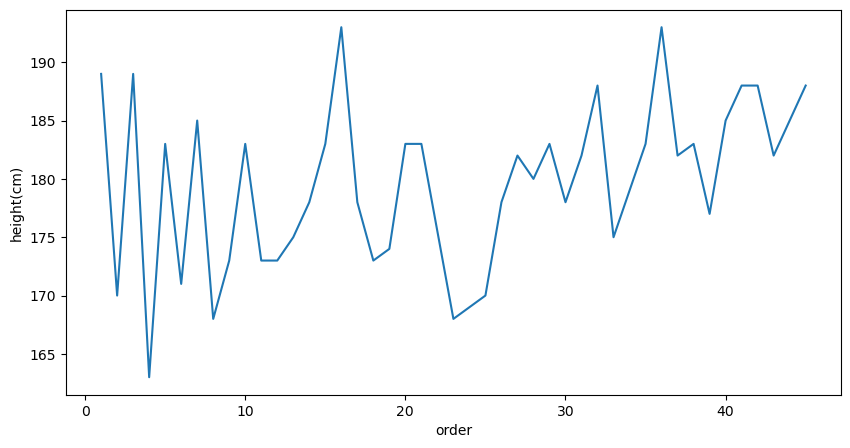

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(data['order'],
         data['height(cm)'])

plt.xlabel('order')
plt.ylabel('height(cm)')

plt.show()

### Names and Values

Notice there can be missing values in DataFrames.

In [37]:
pd.DataFrame([{'a': 1, 'b': 2}, {'b': 3, 'c': 4}])

,a,b,c
0,1.0,2,NaN
1,NaN,3,4.0


You can set indices and columns names *a posteriori*

In [38]:
dfA.columns = ['a','b','c']
dfA.index = [i**2 for i in range(1,6)  ]
dfA

,a,b,c
1,0.568787,0.014452,-0.236633
4,0.915622,1.829420,0.654135
9,2.003139,-0.060429,0.074364
16,1.327383,-1.163866,0.274498
25,0.081817,-0.368399,-0.965909


## Indexing




In [39]:
area = pd.Series( {'California': 423967, 'Texas': 695662, 'New York': 141297, 'Florida': 170312, 'Illinois': 149995})
population = pd.Series({'California': 38332521, 'Texas': 26448193, 'New York': 19651127, 'Florida': 19552860, 'Illinois': 12882135})
states = pd.DataFrame({'Population': population, 'Area': area})
states

,Population,Area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297
Florida,19552860,170312
Illinois,12882135,149995


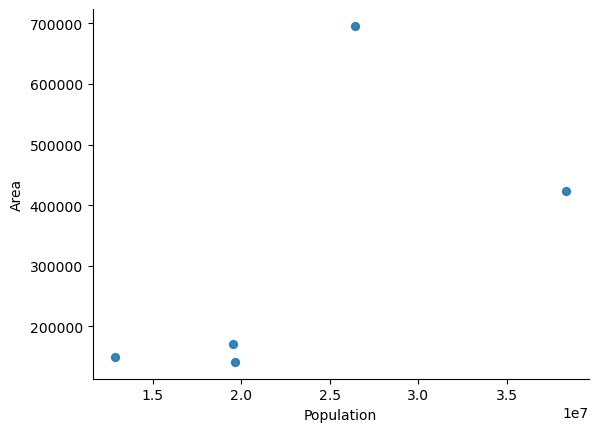

In [ ]:
# @title Population vs Area

from matplotlib import pyplot as plt
states.plot(kind='scatter', x='Population', y='Area', s=32, alpha=.9)
plt.gca().spines[['top', 'right',]].set_visible(False) # we use spines and set_visible because it modern graphs and 
# also in seaborn, top and right side of the graph is visible, it gets easier to read and understand graph in my POV.


You may access columns directly with names, *then* you can access individuals with their index.

In [41]:
states['Area']

California    423967
Texas         695662
New York      141297
Florida       170312
Illinois      149995
Name: Area, dtype: int64

In [42]:
states['Area']['Texas']

np.int64(695662)

To ease the access, Pandas offers dedicated methods:
* <tt>iloc</tt> enables to access subparts of the dataframe as if it was a NumPy array.

In [43]:
states.iloc[:2]

,Population,Area
California,38332521,423967
Texas,26448193,695662


In [44]:
states.iloc[:2,0]

California    38332521
Texas         26448193
Name: Population, dtype: int64

* <tt>loc</tt> does the same but with the explicit names (the last one is included)

In [45]:
states.loc[:'New York']

,Population,Area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297


In [46]:
states.loc[:,'Population':]

,Population,Area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297
Florida,19552860,170312
Illinois,12882135,149995


## Questions and Exercises

**1. Series:**
   - Create a Pandas Series with the following data: [10, 20, 30, 40, 50].
   - Access the third element of the Series.
   - What is the data type of the Series?

**2. DataFrames:**
   - Create a Pandas DataFrame with two columns: 'Name' and 'Age'.
   - Add three rows to the DataFrame with the following data:
     - Name: 'Alice', Age: 25
     - Name: 'Bob', Age: 30
     - Name: 'Charlie', Age: 35
   - Access the 'Age' column of the DataFrame.
   - What is the shape of the DataFrame?

**3. Indexing:**
   - Using the DataFrame from question 2, access the row with the name 'Bob' using `loc`.
   - Access the age of 'Alice' using `iloc`.

**4. File I/O:**
   - Read the 'president_heights.csv' file into a DataFrame.
   - What is the average height of the presidents?
   - What is the name of the tallest president?

**5. Advanced:**
   - Create a DataFrame with three columns: 'A', 'B', and 'C'.
   - Fill the DataFrame with random numbers.
   - Calculate the mean of each column.
   - Add a new column 'D' which is the sum of columns 'A' and 'B'.
   - Sort the DataFrame by column 'D' in descending order.

QUESTION # 1

In [69]:
# Create a pandas series with the following data [10, 20, 30, 40, 50]
my_series = pd.Series([10, 20, 30, 40, 50], index = [0,1,2,3,4])
print(f"My series is given below: \n{my_series}")

# Access the third element of the series
print(f"The third element of my series is: {my_series[2]}")

print(type(my_series))


My series is given below: 
0    10
1    20
2    30
3    40
4    50
dtype: int64
The third element of my series is: 30
<class 'pandas.core.series.Series'>


QUESTION # 2

In [77]:
# Create a Pandas DataFrame with two columns: 'Name' and 'Age'and add three rows to the DataFrame with the following data:
my_df = pd.DataFrame({
        'Name': ['Alice', 'Bob', 'Charlie'],
        'Age': [20, 25, 35]
        })
print(my_df)
#- Access the 'Age' column of the DataFrame.
print(f"\nTHe age column is: {my_df['Age']}")

#- What is the shape of the DataFrame?
print(f"\nThe shape of my DataFrame is: {my_df.shape}")


      Name  Age
0    Alice   20
1      Bob   25
2  Charlie   35

THe age column is: 0    20
1    25
2    35
Name: Age, dtype: int64

The shape of my DataFrame is: (3, 2)


QUESTION # 3

In [97]:
# - Using the DataFrame from question 2, access the row with the name 'Bob' using `loc`.
print(my_df.loc["Bob"])

#- Access the age of 'Alice' using `iloc`.
print(my_df.iloc[0, 0])
print('\n')

Age    25
Name: Bob, dtype: int64
20




QUESTION # 4

In [100]:
# Read the 'president_heights.csv' file into a DataFrame.
new_df =pd.read_csv('president_heights.csv')
new_df

# What is the average height of the presidents?
average_height = new_df['height(cm)'].mean()
print(f"Average Height: {average_height}")

# What is the name of the tallest president?
tallest_president = new_df.loc[new_df["height(cm)"].idxmax(), "name"]
print("Tallest President:", tallest_president)


Average Height: 179.93023255813952
Tallest President: Abraham Lincoln


QUESTION # 5

In [113]:
# Create a DataFrame with three columns: 'A', 'B', and 'C'and fill the DataFrame with random numbers.
df1 = pd.DataFrame(
    np.random.randint(1,100,size=(5,3)),
    columns=['A','B','C']
)

print(df1)

# Calculate the mean of each column.
print('\n')
print(f"The mean of each column is given below: \n{df1.mean()}")

# Add a new column 'D' which is the sum of columns 'A' and 'B'
df1['D'] = df1['A'] + df1['B']

print("\nDataFrame after adding column D:")
print(df1)

# Sort the DataFrame by column 'D' in descending order.
df1_sorted = df1.sort_values(by='D', ascending=False)

print("\nSorted DataFrame:")
print(df1_sorted)

    A   B   C
0  32  71  48
1  82  35  46
2  66  37  84
3  43  63  94
4  96  26  45


The mean of each column is given below: 
A    63.8
B    46.4
C    63.4
dtype: float64

DataFrame after adding column D:
    A   B   C    D
0  32  71  48  103
1  82  35  46  117
2  66  37  84  103
3  43  63  94  106
4  96  26  45  122

Sorted DataFrame:
    A   B   C    D
4  96  26  45  122
1  82  35  46  117
3  43  63  94  106
0  32  71  48  103
2  66  37  84  103
